In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [2]:
load_dotenv()

True

In [3]:

model = ChatGroq(
    model="openai/gpt-oss-120b"
)

In [4]:
class SentimentSchema(BaseModel):

    sentiment: Literal["positive", "negative"] = Field(description='Sentiment of the review')

In [6]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')


In [7]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [8]:
prompt = 'What is the sentiment of the following review - The software too good'
structured_model.invoke(prompt).sentiment

'positive'

In [9]:
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [10]:
def find_sentiment(state: ReviewState):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    
def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}
    

In [11]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')

graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

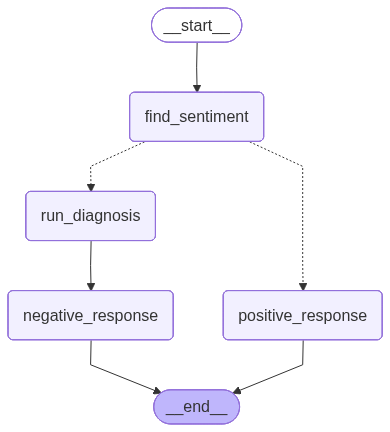

In [12]:
workflow

In [13]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'},
 'response': 'Hi\u202f[Customer Name],\n\nI’m really sorry you’re experiencing this bug and understand how frustrating it must be—especially when you need things to work right away. Thank you for letting us know, and I’m treating this as a top‑priority issue.\n\n**Here’s what we’ll do right now:**\n\n1. **Immediate investigation** – I’ve escalated your case to our senior engineering team, and they are already looking into the root cause.  \n2. **Rapid response** – We’ll keep you updated at least every\u202f2\u202fhours (or sooner if we have new information) until the problem is resolved.  \n3. **Temporary workaround** – If you haven’t tried it yet,

In [14]:
intial_state={
    'review': "I absolutely love using this software! It has made my work so much easier and more efficient. The user interface is intuitive, and the features are exactly what I needed. Keep up the great work!"
    
}
workflow.invoke(intial_state)

{'review': 'I absolutely love using this software! It has made my work so much easier and more efficient. The user interface is intuitive, and the features are exactly what I needed. Keep up the great work!',
 'sentiment': 'positive',
 'response': 'Hi\u202f[Customer Name],\n\nThank you so much for your wonderful review! 🎉 We’re thrilled to hear that our software has made your work easier and more efficient, and that you find the interface intuitive and the features spot‑on. Your kind words truly motivate our team to keep improving and delivering the best experience possible.\n\nIf you have a moment, we’d love for you to share your thoughts on our website as well. Your feedback helps other users discover the product and lets us continue to refine it for you.\n\nThanks again for your support—\u200bwe’re excited to keep serving you!\n\nWarm regards,  \nThe [Your Company] Team'}